In [1]:
# Install required libraries
!pip install scikit-learn pandas matplotlib numpy seaborn

In [2]:
# Import all necessary libraries
import numpy as np                                           
import pandas as pd                                          
import matplotlib.pyplot as plt                             
import seaborn as sns                                        
from sklearn.datasets import load_iris                       
from sklearn.model_selection import train_test_split         
from sklearn.preprocessing import StandardScaler             
from sklearn.linear_model import LogisticRegression          
from sklearn.ensemble import RandomForestClassifier          
from sklearn.svm import SVC                                  
from sklearn.metrics import (
    accuracy_score,                                         
    precision_score,                                         
    recall_score,                                           
    f1_score,                                               
    classification_report,                                   
    confusion_matrix,                                        
    roc_curve,                                              
    auc                                                     
)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


# Load Dataset

In [3]:
# Load the Iris dataset (built-in, no download needed)
# Contains 3 species of flowers with 4 features each
iris = load_iris()

# Convert to pandas DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column (flower species: 0, 1, 2)
df['Species'] = iris.target

# Add species name column for readability
df['Species_Name'] = df['Species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

print("Dataset loaded successfully!")
print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nSpecies Distribution:")
print(df['Species_Name'].value_counts())
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!

Shape: 150 rows x 6 columns

Species Distribution:
Species_Name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species,Species_Name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


# Explore Data

In [4]:
# Check basic statistics
print("Basic Statistics:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Basic Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     Species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Missing Values:
sepal length (cm)    0
sepal width (c

# Visualize Data

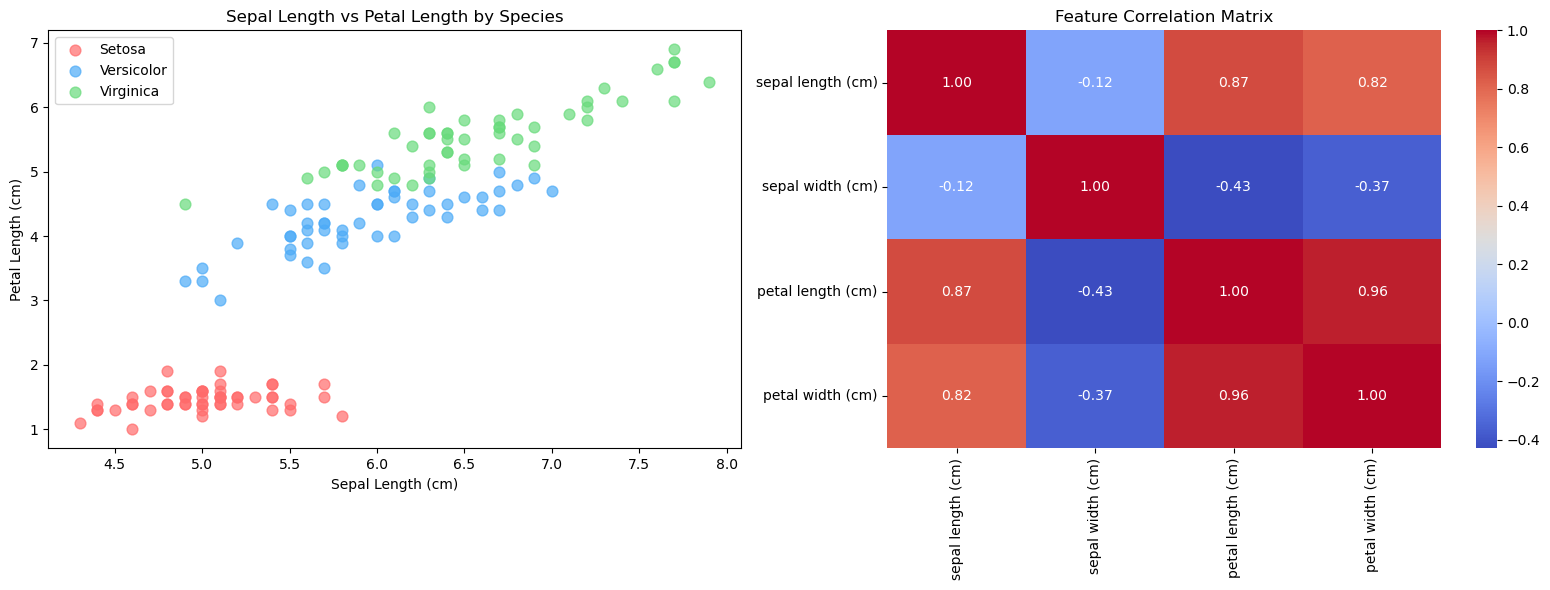

EDA chart saved as 'classification_eda.png'


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Feature distributions by species
colors = ['#ff6b6b', '#4dabf7', '#69db7c']
for idx, species in enumerate(['Setosa', 'Versicolor', 'Virginica']):
    subset = df[df['Species_Name'] == species]
    axes[0].scatter(
        subset['sepal length (cm)'],
        subset['petal length (cm)'],
        label=species,
        color=colors[idx],
        alpha=0.7,
        s=60
    )
axes[0].set_title('Sepal Length vs Petal Length by Species')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Petal Length (cm)')
axes[0].legend()

# Chart 2: Correlation heatmap
sns.heatmap(
    df[iris.feature_names].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=axes[1]
)
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('classification_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA chart saved as 'classification_eda.png'")

# Prepare Data

In [6]:
# Separate features (X) and target variable (y)
X = df[iris.feature_names]    # 4 flower measurement features
y = df['Species']              # Target: species (0, 1, 2)

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    random_state=42,      # Fixed seed for reproducibility
    stratify=y            # Keep equal species ratio in both sets
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing set size  : {X_test.shape[0]} samples")

# Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit and transform training data
X_test_scaled  = scaler.transform(X_test)          # Only transform test data

print("\nFeature scaling complete!")

Training set size : 120 samples
Testing set size  : 30 samples

Feature scaling complete!


# Train Models


In [7]:
# Define all models to compare
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=200),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(probability=True, random_state=42)
}

# Dictionary to store results
results = {}

print("Training models...\n")
print("-" * 60)

for model_name, model in models.items():

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate evaluation metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall    = recall_score(y_test, y_pred, average='weighted')
    f1        = f1_score(y_test, y_pred, average='weighted')

    # Store results
    results[model_name] = {
        'Accuracy' : round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall'   : round(recall, 4),
        'F1 Score' : round(f1, 4),
        'Predictions': y_pred
    }

    print(f"{model_name}:")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print("-" * 60)

Training models...

------------------------------------------------------------
Logistic Regression:
  Accuracy  : 0.9333
  Precision : 0.9333
  Recall    : 0.9333
  F1 Score  : 0.9333
------------------------------------------------------------
Random Forest:
  Accuracy  : 0.9000
  Precision : 0.9024
  Recall    : 0.9000
  F1 Score  : 0.8997
------------------------------------------------------------
SVM:
  Accuracy  : 0.9667
  Precision : 0.9697
  Recall    : 0.9667
  F1 Score  : 0.9666
------------------------------------------------------------


# Compare Models

In [8]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Accuracy' : [results[m]['Accuracy']  for m in results],
    'Precision': [results[m]['Precision'] for m in results],
    'Recall'   : [results[m]['Recall']    for m in results],
    'F1 Score' : [results[m]['F1 Score']  for m in results]
})

print("Model Comparison Table:")
print(comparison_df.to_string(index=False))

# Find best model
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
best_acc   = comparison_df['Accuracy'].max()

print(f"\n🏆 Best Model   : {best_model}")
print(f"   Best Accuracy : {best_acc:.4f}")

Model Comparison Table:
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.9333     0.9333  0.9333    0.9333
      Random Forest    0.9000     0.9024  0.9000    0.8997
                SVM    0.9667     0.9697  0.9667    0.9666

🏆 Best Model   : SVM
   Best Accuracy : 0.9667


# Confusion Matrix

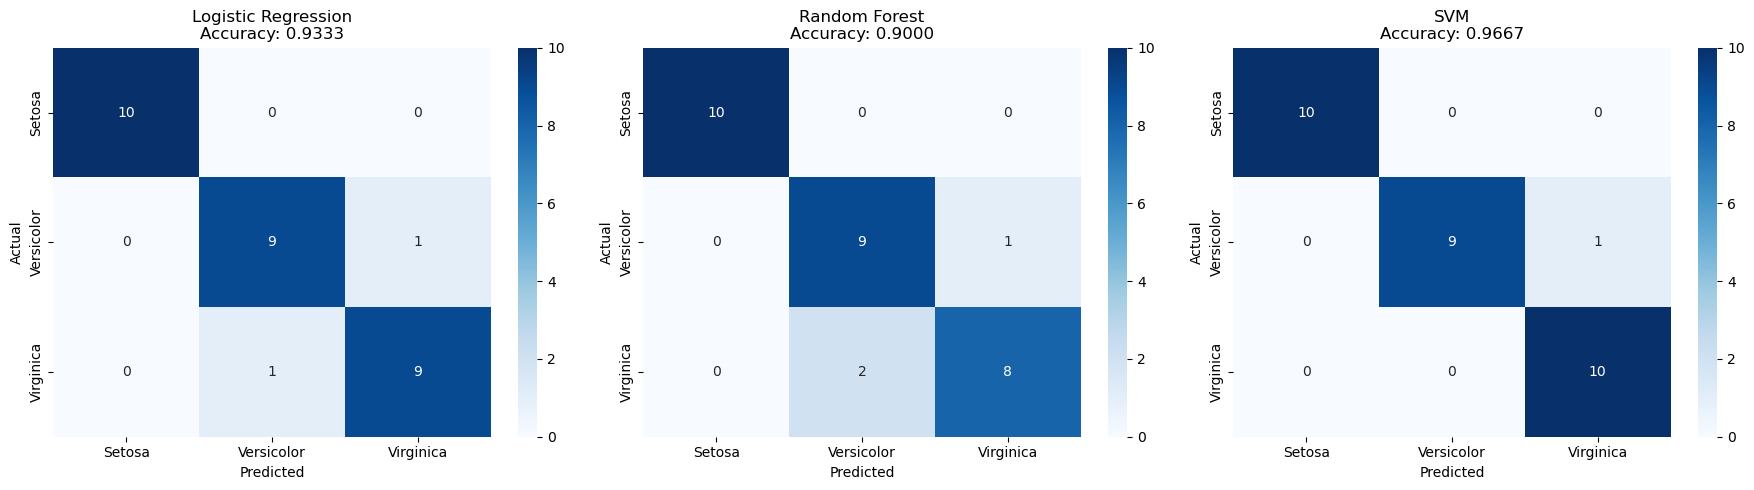

Confusion matrix saved as 'confusion_matrix.png'


In [9]:
# Plot confusion matrix for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
species_names = ['Setosa', 'Versicolor', 'Virginica']

for idx, (model_name, model_results) in enumerate(results.items()):
    cm = confusion_matrix(y_test, model_results['Predictions'])

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=species_names,
        yticklabels=species_names,
        ax=axes[idx]
    )
    axes[idx].set_title(f'{model_name}\nAccuracy: {model_results["Accuracy"]:.4f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'confusion_matrix.png'")

# ROC Curve

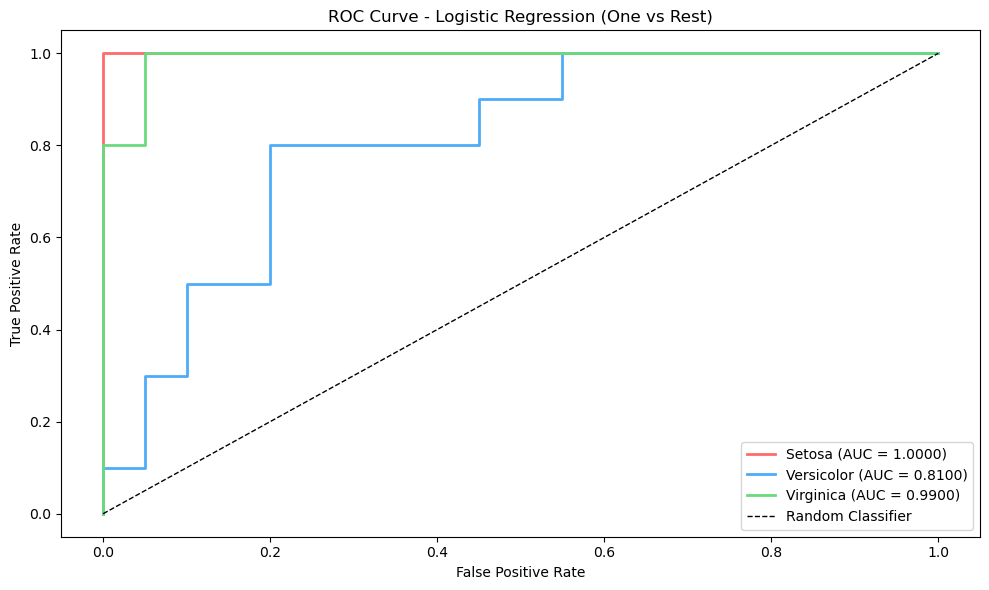

ROC curve saved as 'roc_curve.png'


In [10]:
# Plot ROC curve for Logistic Regression (One vs Rest)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Binarize the output for multiclass ROC
y_bin         = label_binarize(y, classes=[0, 1, 2])
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_train_scaled, y_bin[:len(X_train_scaled)],
    test_size=0.2,
    random_state=42
)

# Train One vs Rest Logistic Regression
ovr_model  = OneVsRestClassifier(LogisticRegression(random_state=42, max_iter=200))
ovr_model.fit(X_train_scaled, label_binarize(y_train, classes=[0, 1, 2]))
y_score    = ovr_model.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Plot ROC curve for each species
plt.figure(figsize=(10, 6))
colors  = ['#ff6b6b', '#4dabf7', '#69db7c']

for i, (species, color) in enumerate(zip(species_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{species} (AUC = {roc_auc:.4f})')

# Random classifier reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.title('ROC Curve - Logistic Regression (One vs Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("ROC curve saved as 'roc_curve.png'")

# Classification Report

In [11]:
# Detailed classification report for best model
print("=" * 60)
print(f"  DETAILED REPORT - {best_model}")
print("=" * 60)
print(classification_report(
    y_test,
    results[best_model]['Predictions'],
    target_names=species_names
))

  DETAILED REPORT - SVM
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Summary

In [12]:
print("=" * 60)
print("  TASK 2 - CLASSIFICATION - SUMMARY")
print("=" * 60)
print(f"\n  Dataset       : Iris Flower Dataset")
print(f"  Total Samples : {df.shape[0]}")
print(f"  Features Used : {len(iris.feature_names)}")
print(f"  Classes       : Setosa, Versicolor, Virginica")
print(f"  Train/Test    : 80% / 20%")
print(f"\n  Model Performance:")
print(comparison_df.to_string(index=False))
print(f"\n  Best Model    : {best_model}")
print(f"  Best Accuracy : {best_acc:.4f}")
print(f"\n  Files Saved:")
print(f"    - classification_eda.png")
print(f"    - confusion_matrix.png")
print(f"    - roc_curve.png")
print("=" * 60)

  TASK 2 - CLASSIFICATION - SUMMARY

  Dataset       : Iris Flower Dataset
  Total Samples : 150
  Features Used : 4
  Classes       : Setosa, Versicolor, Virginica
  Train/Test    : 80% / 20%

  Model Performance:
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.9333     0.9333  0.9333    0.9333
      Random Forest    0.9000     0.9024  0.9000    0.8997
                SVM    0.9667     0.9697  0.9667    0.9666

  Best Model    : SVM
  Best Accuracy : 0.9667

  Files Saved:
    - classification_eda.png
    - confusion_matrix.png
    - roc_curve.png
